# Colour Bitmap Trials — CIELAB Generation

Generate color-oddball bitmaps using the `colour-science` library for CIELAB colour space operations.

**Kernel:** Python (colour-lab)

In [ ]:
import numpy as np
import colour
import matplotlib.pyplot as plt
from PIL import Image

%matplotlib inline

print(f"colour-science {colour.__version__}")
print(f"numpy {np.__version__}")

## Quick Reference: colour-science CIELAB conversions

```python
# sRGB [0,1] → CIE XYZ → CIELAB
XYZ = colour.sRGB_to_XYZ(rgb)          # rgb shape (3,) or (N,3)
Lab = colour.XYZ_to_Lab(XYZ)            # D65 illuminant by default

# CIELAB → CIE XYZ → sRGB
XYZ = colour.Lab_to_XYZ(Lab)
rgb = colour.XYZ_to_sRGB(XYZ)           # may need clipping to [0,1]

# CIELAB → CIELCHab (cylindrical: L*, C*, h°)
LCH = colour.Lab_to_LCHab(Lab)
Lab = colour.LCHab_to_Lab(LCH)
```

In [ ]:
# Smoke test: round-trip sRGB → CIELAB → sRGB
test_rgb = np.array([0.8, 0.2, 0.3])
XYZ = colour.sRGB_to_XYZ(test_rgb)
Lab = colour.XYZ_to_Lab(XYZ)
LCH = colour.Lab_to_LCHab(Lab)

print(f"sRGB:    {test_rgb}")
print(f"CIELAB:  L*={Lab[0]:.2f}, a*={Lab[1]:.2f}, b*={Lab[2]:.2f}")
print(f"CIELCHab: L*={LCH[0]:.2f}, C*={LCH[1]:.2f}, h={LCH[2]:.2f}°")

# Round-trip back
Lab_rt = colour.LCHab_to_Lab(LCH)
XYZ_rt = colour.Lab_to_XYZ(Lab_rt)
rgb_rt = colour.XYZ_to_sRGB(XYZ_rt)
print(f"\nRound-trip sRGB: {rgb_rt} (max error: {np.max(np.abs(test_rgb - rgb_rt)):.2e})")

In [ ]:
print(colour.COLOURSPACE_MODELS)

#example: converting CIE XYZ TO CIE LAB
colour.XYZ_to_Lab([0.20654008, 0.12197225, 0.05136952])

# Warm red-orange
base_lch = np.array([55.0, 60.0, 30.0])   # [L*, C*, H°]

# Sky blue
base_lch = np.array([60.0, 45.0, 220.0])


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from skimage.color import lab2rgb

def show_lab_palette(L=60, a=20, b=10, palette_de=5, n_shades=7):
    """Show a LAB-anchored palette stepping tangentially (hue direction) by palette_de ΔE per shade."""
    C = np.sqrt(a**2 + b**2)
    offsets = np.arange(n_shades) - (n_shades - 1) / 2.0
    a_vals = a + offsets * palette_de * (-b / C)
    b_vals = b + offsets * palette_de * (a / C)

    lab = np.stack([np.full(n_shades, L), a_vals, b_vals], axis=1)
    rgb = np.clip(lab2rgb(lab.reshape(1, -1, 3))[0], 0, 1)
    rgb_255 = np.round(rgb * 255).astype(np.uint8)

    fig, ax = plt.subplots(figsize=(n_shades * 1.2, 1.5))
    for i, color in enumerate(rgb):
        ax.add_patch(patches.Rectangle((i, 0), 1, 1, color=color))
    ax.set_xlim(0, n_shades)
    ax.set_ylim(0, 1)
    ax.axis('off')
    plt.title(f"L={L}, a={a}, b={b}, palette_ΔE={palette_de}, n={n_shades}")
    plt.tight_layout()
    plt.show()

    print(f"L={L}, a={a}, b={b}, palette_de={palette_de}, n_shades={n_shades}")
    for i, (c, av, bv) in enumerate(zip(rgb_255, a_vals, b_vals)):
        print(f"  shade {i+1}: RGB({c[0]:3d}, {c[1]:3d}, {c[2]:3d})  [a*={av:.1f}, b*={bv:.1f}]")
    print()

    return rgb_255


In [ ]:
# ── Bitmap generation utilities ───────────────────────────────────────────────

from skimage.color import rgb2lab

BITMAP_SIZE = 400
TILE_GRID   = 20   # default grid size (20×20 = 400 cells)


def generate_base_proportions(n_shades, rng):
    """Mildly uneven Dirichlet proportions for n shades, sorted descending."""
    props = rng.dirichlet(np.full(n_shades, 3.0))
    props.sort()
    return props[::-1]


def shift_proportions(base_proportions, shift_amount, rng):
    """Move shift_amount of probability mass from the dominant shade to a random other."""
    props = base_proportions.copy()
    donor = int(np.argmax(props))
    others = [i for i in range(len(props)) if i != donor]
    recipient = others[rng.randint(len(others))]
    props[donor]     -= shift_amount / 2.0
    props[recipient] += shift_amount / 2.0
    props = np.maximum(props, 0.005)
    props /= props.sum()
    return props


def generate_bitmap(colors_rgb, proportions, rng, tile_grid=TILE_GRID):
    """Paint a grid with colors at given proportions.
    tile_grid controls the number of squares per side (larger = more, smaller squares).
    Output size = cell_size * tile_grid — avoids black borders when BITMAP_SIZE
    is not evenly divisible by tile_grid (e.g. tile_grid=15 → 390×390 not 400×400).
    """
    cell_size   = BITMAP_SIZE // tile_grid
    out_size    = cell_size * tile_grid      # actual image size, no leftover pixels
    total_cells = tile_grid * tile_grid

    cell_counts = np.round(proportions * total_cells).astype(int)
    cell_counts[0] += total_cells - cell_counts.sum()

    cell_colors = np.repeat(np.arange(len(colors_rgb)), cell_counts)
    rng.shuffle(cell_colors)

    bitmap = np.zeros((out_size, out_size, 3), dtype=np.uint8)
    for idx, ci in enumerate(cell_colors):
        row, col = divmod(idx, tile_grid)
        y0, x0 = row * cell_size, col * cell_size
        bitmap[y0:y0 + cell_size, x0:x0 + cell_size] = colors_rgb[ci]
    return bitmap


def equalize_luminance(colors_rgb):
    """Set all shades to the same mean L*, preserving a* and b*."""
    lab = rgb2lab(colors_rgb.reshape(1, -1, 3).astype(np.float64) / 255.0)[0]
    lab[:, 0] = np.mean(lab[:, 0])
    rgb_f = lab2rgb(lab.reshape(1, -1, 3))[0]
    return np.clip(np.round(rgb_f * 255), 0, 255).astype(np.uint8)


def show_bitmaps(distractor_colors, oddball_colors, distractor_props, oddball_props, rng, title="", tile_grid=TILE_GRID):
    """Display the 4AFC bitmap set (1 oddball + 3 distractors) side by side."""
    bitmaps = [generate_bitmap(oddball_colors,    oddball_props,    rng, tile_grid)] + \
              [generate_bitmap(distractor_colors, distractor_props, rng, tile_grid) for _ in range(3)]
    labels = ["oddball", "distractor", "distractor", "distractor"]

    fig, axes = plt.subplots(1, 4, figsize=(14, 3.5))
    if title:
        fig.suptitle(title, fontsize=11)
    for ax, bm, lbl in zip(axes, bitmaps, labels):
        ax.imshow(bm)
        ax.set_title(lbl, fontsize=9)
        ax.axis('off')
    plt.tight_layout()
    plt.show()


print("Bitmap utilities loaded.")


In [ ]:
def lab_palette_colors(L, a, b, palette_de, n_shades):
    """Return (n_shades, 3) uint8 RGB stepping tangentially by palette_de ΔE per shade."""
    C = np.sqrt(a**2 + b**2)
    offsets = np.arange(n_shades) - (n_shades - 1) / 2.0
    lab = np.stack([np.full(n_shades, L),
                    a + offsets * palette_de * (-b / C),
                    b + offsets * palette_de * (a / C)], axis=1)
    rgb = np.clip(lab2rgb(lab.reshape(1, -1, 3))[0], 0, 1)
    return np.round(rgb * 255).astype(np.uint8)


def rotate_ab(a, b, deg):
    """Rotate an (a*, b*) anchor point by deg degrees in the a*-b* plane."""
    C = np.sqrt(a**2 + b**2)
    h = np.arctan2(b, a) + np.deg2rad(deg)
    return C * np.cos(h), C * np.sin(h)


# Suggested oddball_de difficulty levels (ΔE units)
# Easy: clearly distinguishable; Hard: perceptually similar to distractors
DIFFICULTY_LEVELS = {
    "easy":   20,   # clearly different hue
    "medium": 10,   # noticeable but requires attention
    "hard":   5,    # subtle, near-threshold
}


def make_trial(L, a, b, palette_de, oddball_de, n_shades=10, seed=42,
               tile_grid=TILE_GRID, export_dir=None):
    """
    Generate a 4AFC hue-oddball trial.

    Parameters
    ----------
    L, a, b      : CIELAB anchor (defines base hue and chroma)
    palette_de   : ΔE between adjacent shades within the palette (within-bitmap spread)
    oddball_de   : ΔE between distractor and oddball anchor points (oddball signal)
    n_shades     : number of shades in the palette
    seed         : random seed (controls both tile layout and shade proportions)
    tile_grid    : number of squares per side (e.g. 10=large squares, 20=small squares)
    export_dir   : if set, saves the 4 bitmaps as PNGs to this directory

    Design note
    -----------
    Each bitmap gets independently sampled shade proportions so that distribution
    is non-diagnostic — color is the only dimension that distinguishes the oddball.
    """
    rng = np.random.RandomState(seed)

    dist_colors = lab_palette_colors(L, a, b, palette_de, n_shades)

    C = np.sqrt(a**2 + b**2)
    deg = np.degrees(2 * np.arcsin(np.clip(oddball_de / (2 * C), 0, 1)))
    a_odd, b_odd = rotate_ab(a, b, deg)
    odd_colors = lab_palette_colors(L, a_odd, b_odd, palette_de, n_shades)

    rng2 = np.random.RandomState(seed + 1)
    bitmaps = [generate_bitmap(odd_colors,  generate_base_proportions(n_shades, rng), rng2, tile_grid)] + \
              [generate_bitmap(dist_colors, generate_base_proportions(n_shades, rng), rng2, tile_grid)
               for _ in range(3)]
    labels = ["oddball", "distractor1", "distractor2", "distractor3"]

    # Show palettes
    fig, axes = plt.subplots(1, 2, figsize=(n_shades * 1.2, 1.8))
    for ax, colors_rgb, label in zip(axes,
                                     [dist_colors, odd_colors],
                                     ["distractors", f"oddball (ΔE={oddball_de})"]):
        rgb_f = colors_rgb.astype(np.float64) / 255.0
        for i, c in enumerate(rgb_f):
            ax.add_patch(plt.Rectangle((i, 0), 1, 1, color=c))
        ax.set_xlim(0, n_shades)
        ax.set_ylim(0, 1)
        ax.axis('off')
        ax.set_title(label, fontsize=9)
    plt.suptitle(f"L={L}, a={a}, b={b} | palette_ΔE={palette_de}, oddball_ΔE={oddball_de}, n={n_shades}", fontsize=10)
    plt.tight_layout()
    plt.show()

    # Show bitmaps
    fig, axes = plt.subplots(1, 4, figsize=(14, 3.5))
    plt.suptitle(f"palette_ΔE={palette_de}  |  oddball_ΔE={oddball_de}  |  tile_grid={tile_grid}", fontsize=11)
    for ax, bm, lbl in zip(axes, bitmaps, labels):
        ax.imshow(bm)
        ax.set_title(lbl, fontsize=9)
        ax.axis('off')
    plt.tight_layout()
    plt.show()

    if export_dir is not None:
        import os
        from PIL import Image as PILImage
        os.makedirs(export_dir, exist_ok=True)
        stem = f"L{L}_a{a}_b{b}_pde{palette_de}_ode{oddball_de}_n{n_shades}_tg{tile_grid}_seed{seed}"
        for bm, lbl in zip(bitmaps, labels):
            PILImage.fromarray(bm).save(os.path.join(export_dir, f"{stem}_{lbl}.png"))
        print(f"Saved 4 bitmaps to {export_dir}/  [{stem}_*.png]")


# ── Example ───────────────────────────────────────────────────────────────────
make_trial(L=70, a=-75, b=45, palette_de=2, oddball_de=15, n_shades=15)


In [ ]:
#PURPLE-PINK  (anchor C ≈ 92, so 1° ≈ ΔE 1.6)
make_trial(L=50, a=70, b=-60, palette_de=1, oddball_de=1,  n_shades=20)
make_trial(L=50, a=70, b=-60, palette_de=2, oddball_de=4,  n_shades=5)



#make_trial(L=60, a=70, b=-60, palette_de=4, oddball_de=3,  n_shades=10)
#make_trial(L=60, a=70, b=-60, palette_de=4, oddball_de=5,  n_shades=10)
#make_trial(L=60, a=70, b=-60, palette_de=4, oddball_de=10, n_shades=10)
#make_trial(L=60, a=70, b=-60, palette_de=4, oddball_de=15, n_shades=10)


In [ ]:
#ORANGE  (anchor C = 100)
make_trial(L=90, a=60, b=80, palette_de=2, oddball_de=2,  n_shades=20)
make_trial(L=60, a=60, b=80, palette_de=5, oddball_de=10, n_shades=10)
make_trial(L=60, a=60, b=80, palette_de=5, oddball_de=16, n_shades=10)


In [ ]:
#TEAL  (anchor C ≈ 83)
make_trial(L=60, a=-80, b=-20, palette_de=7, oddball_de=4,  n_shades=10)
make_trial(L=60, a=-80, b=-20, palette_de=4, oddball_de=8,  n_shades=10)


#make_trial(L=60, a=-80, b=-20, palette_de=7, oddball_de=9,  n_shades=10)
#make_trial(L=60, a=-80, b=-20, palette_de=7, oddball_de=13, n_shades=10)


## Palette → Bitmap workflow

1. Pick anchor (L, a, b) — defines the base hue and chroma
2. Set `palette_de` — ΔE between adjacent shades (within-bitmap spread)
3. Set `oddball_de` — ΔE between distractor and oddball anchor points (oddball signal)
4. Call `make_trial(L, a, b, palette_de, oddball_de, n_shades)`

**Difficulty landmarks (CIELAB ΔE):**
- ΔE ~1–2: near threshold
- ΔE ~5–10: clearly discriminable, similar category
- ΔE ~20+: categorically different

**Note:** Effective oddball discriminability ≈ `oddball_de − palette_de × (n_shades / 2)`.
A wider palette requires a larger `oddball_de` to place the oddball outside the distractor range.


In [ ]:
import os

# ── Hue anchor configs ────────────────────────────────────────────────────────
# Each entry: (L, a, b, palette_de, n_shades)
# Fill in placeholders as you settle on anchors

HUE_CONFIGS = {
   # "Y":   (..., ..., ..., ..., ...),   # yellow       — not yet defined
  #  "O":   (..., ..., ..., ..., ...),   # orange       — not yet defined
    "R":   (60,  70, -60,    4,  10),   # red-pink     — from cell-9
  #  "Pi":  (..., ..., ..., ..., ...),   # pink         — not yet defined
  #  "Pur": (..., ..., ..., ..., ...),   # purple       — not yet defined
    "B":   (60, -80, -20,    5,  10),   # blue         — from cell-11
    "G":   (60,  60,  80,    5,  10),   # yellow-green — from cell-10
}

SEEDS = list(range(10))   # 10 spatial layouts per condition

# Placeholder oddball_de — replace with calibrated values after piloting
PLACEHOLDER_ODE = 15


def export_palettes(hue_configs, oddball_de, seeds, export_dir="trial_exports"):
    """Export bitmap trials for all defined hue anchors."""
    for hue, config in hue_configs.items():
        if ... in config:
            print(f"Skipping {hue} — anchor not yet defined")
            continue
        L, a, b, palette_de, n_shades = config
        for seed in seeds:
            make_trial(L, a, b,
                       palette_de = palette_de,
                       oddball_de = oddball_de,
                       n_shades   = n_shades,
                       seed       = seed,
                       export_dir = os.path.join(export_dir, hue))


# Uncomment to run:
export_palettes(HUE_CONFIGS, oddball_de=PLACEHOLDER_ODE, seeds=SEEDS)


In [ ]:
# generating hue rings
export_folder = '/Users/momueller/Dropbox (Personal)/Vandy/Projects/SceneFactor_OPLab/Melina/bitmap_trials'

In [ ]:
def generate_hue_ring(L, C, n_colors, offset_deg=0):
    """
    Sample n_colors evenly around the a*/b* plane at fixed luminance (L) and chroma (C).
    offset_deg rotates the entire ring.
    Returns (n_colors, 3) uint8 RGB array.
    """
    angles = np.linspace(0, 360, n_colors, endpoint=False) + offset_deg
    a_vals = C * np.cos(np.deg2rad(angles))
    b_vals = C * np.sin(np.deg2rad(angles))

    lab = np.stack([np.full(n_colors, L), a_vals, b_vals], axis=1)
    rgb = np.clip(lab2rgb(lab.reshape(1, -1, 3))[0], 0, 1)
    return np.round(rgb * 255).astype(np.uint8)


def select_pairs(ring_rgb, min_de, max_de):
    """
    Return all (i, j) index pairs from ring_rgb whose ΔE falls within [min_de, max_de].
    ΔE is computed in CIELAB from the RGB values.
    """
    lab = rgb2lab(ring_rgb.reshape(1, -1, 3).astype(np.float64) / 255.0)[0]
    pairs = []
    n = len(lab)
    for i in range(n):
        for j in range(i + 1, n):
            de = np.sqrt(np.sum((lab[i] - lab[j]) ** 2))
            if min_de <= de <= max_de:
                pairs.append((i, j))
    return pairs


def make_trial_from_pair(L, dist_ab, odd_ab, palette_de, n_shades=10,
                         seed=42, tile_grid=TILE_GRID, export_dir=None):
    """
    Like make_trial, but takes explicit distractor and oddball anchors
    instead of computing the oddball via rotation.

    dist_ab, odd_ab : (a, b) tuples for the distractor and oddball anchors
    tile_grid       : number of squares per side (e.g. 10=large, 20=small)

    Returns
    -------
    bitmaps : [oddball, distractor1, distractor2, distractor3] as uint8 arrays
    """
    rng  = np.random.RandomState(seed)
    rng2 = np.random.RandomState(seed + 1)

    dist_colors = lab_palette_colors(L, dist_ab[0], dist_ab[1], palette_de, n_shades)
    odd_colors  = lab_palette_colors(L,  odd_ab[0],  odd_ab[1], palette_de, n_shades)

    de = np.sqrt((dist_ab[0] - odd_ab[0])**2 + (dist_ab[1] - odd_ab[1])**2)

    bitmaps = [generate_bitmap(odd_colors,  generate_base_proportions(n_shades, rng), rng2, tile_grid)] + \
              [generate_bitmap(dist_colors, generate_base_proportions(n_shades, rng), rng2, tile_grid)
               for _ in range(3)]
    labels = ["oddball", "distractor1", "distractor2", "distractor3"]

    # Show palettes
    fig, axes = plt.subplots(1, 2, figsize=(n_shades * 1.2, 1.8))
    for ax, colors_rgb, label in zip(axes,
                                     [dist_colors, odd_colors],
                                     ["distractors", f"oddball (ΔE={de:.1f})"]):
        rgb_f = colors_rgb.astype(np.float64) / 255.0
        for i, c in enumerate(rgb_f):
            ax.add_patch(plt.Rectangle((i, 0), 1, 1, color=c))
        ax.set_xlim(0, n_shades)
        ax.set_ylim(0, 1)
        ax.axis('off')
        ax.set_title(label, fontsize=9)
    plt.suptitle(f"L={L}, dist_ab={dist_ab}, odd_ab={odd_ab} | palette_ΔE={palette_de}", fontsize=10)
    plt.tight_layout()
    plt.show()

    # Show bitmaps
    fig, axes = plt.subplots(1, 4, figsize=(14, 3.5))
    plt.suptitle(f"palette_ΔE={palette_de}  |  oddball_ΔE={de:.1f}  |  tile_grid={tile_grid}", fontsize=11)
    for ax, bm, lbl in zip(axes, bitmaps, labels):
        ax.imshow(bm)
        ax.set_title(lbl, fontsize=9)
        ax.axis('off')
    plt.tight_layout()
    plt.show()

    if export_dir is not None:
        os.makedirs(export_dir, exist_ok=True)
        stem = f"L{L}_dist{dist_ab}_odd{odd_ab}_pde{palette_de}_tg{tile_grid}_seed{seed}"
        for bm, lbl in zip(bitmaps, labels):
            PILImage.fromarray(bm).save(os.path.join(export_dir, f"{stem}_{lbl}.png"))
        print(f"Saved to {export_dir}/  [{stem}_*.png]")

    return bitmaps


In [ ]:
ring = generate_hue_ring(L=80, C=80, n_colors=36, offset_deg=0)
pairs = select_pairs(ring, min_de=5, max_de=20)

lab = rgb2lab(ring.reshape(1,-1,3).astype(np.float64)/255.0)[0]
for i, j in pairs:
    make_trial_from_pair(L=60,
                         dist_ab=(lab[i,1], lab[i,2]),
                         odd_ab =(lab[j,1], lab[j,2]),
                         palette_de=5, n_shades=10)


In [ ]:
ring = generate_hue_ring(L=60, C=80, n_colors=36, offset_deg=0)
pairs = select_pairs(ring, min_de=5, max_de=20)

lab = rgb2lab(ring.reshape(1,-1,3).astype(np.float64)/255.0)[0]
for i, j in pairs:
    make_trial_from_pair(L=80,
                         dist_ab=(lab[i,1], lab[i,2]),
                         odd_ab =(lab[j,1], lab[j,2]),
                         palette_de=5, n_shades=10)

In [ ]:
import base64, io
from PIL import Image as PILImage

def export_html(trial_sets, output_path="trial_gallery.html"):
    """
    trial_sets: list of dicts, each with:
        'bitmaps' : [oddball, dist1, dist2, dist3] as numpy arrays
        'title'   : string describing the trial
    """

    def to_base64(arr):
        buf = io.BytesIO()
        PILImage.fromarray(arr).save(buf, format="PNG")
        return base64.b64encode(buf.getvalue()).decode()

    rows = []
    for trial in trial_sets:
        labels = ["oddball", "distractor 1", "distractor 2", "distractor 3"]
        imgs = "".join(
            f"""<div style="text-align:center; font-family:sans-serif">
                  <img src="data:image/png;base64,{to_base64(bm)}" width="180"/>
                  <p style="margin:4px">{lbl}</p>
                </div>"""
            for bm, lbl in zip(trial["bitmaps"], labels)
        )
        rows.append(
            f"""<div style="margin-bottom:30px">
                  <h3 style="font-family:sans-serif">{trial["title"]}</h3>
                  <div style="display:flex; gap:12px">{imgs}</div>
                </div><hr/>"""
        )

    html = f"<html><body>{''.join(rows)}</body></html>"
    with open(output_path, "w") as f:
        f.write(html)
    print(f"Saved → {output_path}")


In [ ]:
# ── HTML + PNG export workflow ────────────────────────────────────────────────
# Collect trials from a ring, export as a shareable HTML file AND individual PNGs.
# Oddball is always first in each set.

ring  = generate_hue_ring(L=70, C=80, n_colors=36, offset_deg=0)
pairs = select_pairs(ring, min_de=2, max_de=20)
lab   = rgb2lab(ring.reshape(1, -1, 3).astype(np.float64) / 255.0)[0]

png_dir  = os.path.join(export_folder, "pngs_L70")    # folder for individual PNGs
html_out = os.path.join(export_folder, "trial_gallery_L70.html")

trial_sets = []
for i, j in pairs:
    dist_ab = (lab[i, 1], lab[i, 2])
    odd_ab  = (lab[j, 1], lab[j, 2])
    de      = np.sqrt((dist_ab[0] - odd_ab[0])**2 + (dist_ab[1] - odd_ab[1])**2)

    bitmaps = make_trial_from_pair(
        L          = lab[i, 0],
        dist_ab    = dist_ab,
        odd_ab     = odd_ab,
        palette_de = 5,
        n_shades   = 10,
        seed       = 42,
        export_dir = png_dir,     # saves 4 PNGs per trial
    )
    trial_sets.append({
        "bitmaps": bitmaps,
        "title": f"dist=({dist_ab[0]:.1f}, {dist_ab[1]:.1f})  "
                 f"odd=({odd_ab[0]:.1f}, {odd_ab[1]:.1f})  ΔE={de:.1f}"
    })

export_html(trial_sets, output_path=html_out)


In [ ]:
# ── HTML + PNG export — 16×16 grid ───────────────────────────────────────────

ring  = generate_hue_ring(L=60, C=80, n_colors=72, offset_deg=0)
pairs = select_pairs(ring, min_de=1, max_de=5)#CHANGED FROM min_de 5 to 2 and max from 20 to 12
lab   = rgb2lab(ring.reshape(1, -1, 3).astype(np.float64) / 255.0)[0]

png_dir  = os.path.join(export_folder, "pngs_L60_tg20_minDE_1_maxDE_5_72c")
html_out = os.path.join(export_folder, "trial_gallery_L60_tg20_minDE_1_maxDE_5_72c.html")

trial_sets = []
for i, j in pairs:
    dist_ab = (lab[i, 1], lab[i, 2])
    odd_ab  = (lab[j, 1], lab[j, 2])
    de      = np.sqrt((dist_ab[0] - odd_ab[0])**2 + (dist_ab[1] - odd_ab[1])**2)

    bitmaps = make_trial_from_pair(
        L          = lab[i, 0],
        dist_ab    = dist_ab,
        odd_ab     = odd_ab,
        palette_de = 5,
        n_shades   = 10,
        seed       = 42,
        tile_grid  = 20,
        export_dir = png_dir,
    )
    trial_sets.append({
        "bitmaps": bitmaps,
        "title": f"dist=({dist_ab[0]:.1f}, {dist_ab[1]:.1f})  "
                 f"odd=({odd_ab[0]:.1f}, {odd_ab[1]:.1f})  ΔE={de:.1f}  grid=20×20"
    })

export_html(trial_sets, output_path=html_out)


In [ ]:
def show_hue_ring(L, C, n_colors, offset_deg=0, export_dir="trial_exports"):
    ring = generate_hue_ring(L, C, n_colors, offset_deg)
    img = ring.reshape(1, n_colors, 3)

    fig, ax = plt.subplots(figsize=(n_colors * 0.6, 1.5))
    ax.imshow(img, aspect='auto')
    ax.axis('off')
    ax.set_title(f"Hue ring — L={L}, C={C}, n={n_colors}, offset={offset_deg}°", fontsize=10)
    plt.tight_layout()

    os.makedirs(export_dir, exist_ok=True)
    path = os.path.join(export_dir, f"hue_ring_L{L}_C{C}_n{n_colors}_offset{offset_deg}.png")
    plt.savefig(path, dpi=150, bbox_inches='tight')
    plt.close(fig)
    print(f"Saved → {path}")

    return ring

show_hue_ring(L=40, C=80, n_colors=72, offset_deg=0, export_dir=export_folder)


## Platykurtic distribution — concept test

One shared palette of N colors. Distractors and oddball sample from the **same** color range,
but with distributions centered at different points. The oddball's mean is shifted; the extremes are identical.

- `sigma` controls flatness — larger = more platykurtic (broader/flatter)
- `mean_shift` controls how far the oddball mean is from the distractor mean (in palette indices)


In [ ]:
def platykurtic_proportions(n_colors, mean_idx, sigma, alpha=0.3):
    """
    Uniform floor + Gaussian peak distribution.
    alpha controls peakedness: 0 = flat, 1 = pure Gaussian.
    Both distributions share the same uniform floor → same extremes.
    """
    indices  = np.arange(n_colors, dtype=float)
    uniform  = np.ones(n_colors) / n_colors
    gaussian = np.exp(-0.5 * ((indices - mean_idx) / sigma) ** 2)
    gaussian /= gaussian.sum()
    weights  = (1 - alpha) * uniform + alpha * gaussian
    return weights / weights.sum()


def make_trial_platykurtic(L, a, b, n_colors=20, palette_de=3,
                            sigma=6, mean_shift=5, seed=42,
                            tile_grid=TILE_GRID):
    """
    4AFC trial using a shared palette with a shifted mean.

    One palette of n_colors is shared between distractors and oddball.
    Distractors: distribution centered at palette midpoint.
    Oddball:     distribution centered at midpoint + mean_shift.
    Extremes (min/max colors) are identical for both.

    Parameters
    ----------
    n_colors   : number of shades in the shared palette
    palette_de : ΔE between adjacent shades (controls color range)
    sigma      : distribution width — larger = flatter/more platykurtic
    mean_shift : how many shades to shift the oddball mean
    """
    rng  = np.random.RandomState(seed)
    rng2 = np.random.RandomState(seed + 1)

    # One shared palette
    colors = lab_palette_colors(L, a, b, palette_de, n_colors)

    midpoint   = (n_colors - 1) / 2.0
    dist_props = platykurtic_proportions(n_colors, midpoint,              sigma)
    odd_props  = platykurtic_proportions(n_colors, midpoint + mean_shift, sigma)

    # 4 bitmaps — oddball first
    bitmaps = [generate_bitmap(colors, odd_props,  rng2, tile_grid)] + \
              [generate_bitmap(colors, dist_props, rng2, tile_grid) for _ in range(3)]
    labels  = ["oddball", "distractor1", "distractor2", "distractor3"]

    # Show shared palette
    fig, ax = plt.subplots(figsize=(n_colors * 0.7, 1.2))
    for i, c in enumerate(colors.astype(float) / 255.0):
        ax.add_patch(plt.Rectangle((i, 0), 1, 1, color=c))
    ax.set_xlim(0, n_colors)
    ax.set_ylim(0, 1)
    ax.axis('off')
    plt.title(f"Shared palette — L={L}, a={a}, b={b}, palette_ΔE={palette_de}, n={n_colors}", fontsize=9)
    plt.tight_layout()
    plt.show()

    # Show distributions
    fig, axes = plt.subplots(1, 2, figsize=(8, 2))
    x = np.arange(n_colors)
    axes[0].bar(x, dist_props, color='steelblue');  axes[0].set_title("distractor distribution", fontsize=9)
    axes[1].bar(x, odd_props,  color='tomato');     axes[1].set_title(f"oddball distribution (shift={mean_shift})", fontsize=9)
    for ax in axes:
        ax.set_xlabel("shade index"); ax.set_ylabel("proportion"); ax.set_ylim(0, max(odd_props.max(), dist_props.max()) * 1.2)
    plt.suptitle(f"sigma={sigma}  |  mean_shift={mean_shift}", fontsize=10)
    plt.tight_layout()
    plt.show()

    # Show bitmaps
    fig, axes = plt.subplots(1, 4, figsize=(14, 3.5))
    plt.suptitle(f"platykurtic  |  sigma={sigma}  |  mean_shift={mean_shift}  |  tile_grid={tile_grid}", fontsize=10)
    for ax, bm, lbl in zip(axes, bitmaps, labels):
        ax.imshow(bm); ax.set_title(lbl, fontsize=9); ax.axis('off')
    plt.tight_layout()
    plt.show()


# ── Test on a few palettes ────────────────────────────────────────────────────
make_trial_platykurtic(L=50, a=-70,  b=-60, n_colors=30, palette_de=3, sigma=3, mean_shift=6)   # BG
make_trial_platykurtic(L=50, a=-70,  b=-60, n_colors=15, palette_de=3, sigma=3, mean_shift=6)   # BG
make_trial_platykurtic(L=50, a=-70,  b=-60, n_colors=10, palette_de=3, sigma=3, mean_shift=6)   # BG
make_trial_platykurtic(L=50, a=-70,  b=-60, n_colors=5, palette_de=3, sigma=3, mean_shift=3)   # BG


make_trial_platykurtic(L=60, a=70,  b=-60, n_colors=30, palette_de=3, sigma=12, mean_shift=6)   # red-pink2 
make_trial_platykurtic(L=60, a=70,  b=-60, n_colors=15, palette_de=3, sigma=12, mean_shift=6)   # red-pink2 
make_trial_platykurtic(L=60, a=70,  b=-60, n_colors=10, palette_de=3, sigma=12, mean_shift=6)   # red-pink2 


#make_trial_platykurtic(L=60, a=-80, b=-20, n_colors=15, palette_de=3, sigma=6, mean_shift=4)   # blue
#make_trial_platykurtic(L=60, a=60,  b=80,  n_colors=10, palette_de=3, sigma=6, mean_shift=3)   # yellow-green


In [ ]:
def platykurtic_proportions(n_colors, mean_idx, sigma):
    indices  = np.arange(n_colors, dtype=float)
    uniform  = np.ones(n_colors) / n_colors
    gaussian = np.exp(-0.5 * ((indices - mean_idx) / sigma) ** 2)
    gaussian /= gaussian.sum()
    weights  = 0.5 * uniform + 0.5 * gaussian
    return weights / weights.sum()
def make_trial_platykurtic2(L, a, b, n_colors=20, palette_de=4,
                             sigma=5, mean_shift=7, seed=42, tile_grid=TILE_GRID):
    colors     = lab_palette_colors(L, a, b, palette_de, n_colors)
    midpoint   = (n_colors - 1) / 2.0
    dist_props = platykurtic_proportions(n_colors, midpoint,              sigma)
    odd_props  = platykurtic_proportions(n_colors, midpoint + mean_shift, sigma)

    bitmaps = [generate_bitmap(colors, odd_props,  np.random.RandomState(seed))] + \
              [generate_bitmap(colors, dist_props, np.random.RandomState(seed + i + 1))
               for i in range(3)]
    return colors, dist_props, odd_props, bitmaps


In [39]:
def compare_methods(L, a, b, oddball_de=5, palette_de=4, n_shades=20,
                    
                    n_colors=10, sigma=3, mean_shift=2, seed=42):

    # Method 1
    dist_colors = lab_palette_colors(L, a, b, palette_de, n_shades)
    a_odd, b_odd = rotate_ab(a, b, oddball_de)
    odd_colors   = lab_palette_colors(L, a_odd, b_odd, palette_de, n_shades)
    props        = np.ones(n_shades) / n_shades
    bm1 = [generate_bitmap(odd_colors,  props, np.random.RandomState(seed))] + \
          [generate_bitmap(dist_colors, props, np.random.RandomState(seed + i + 1))
           for i in range(3)]

    # Method 2
    colors, dist_props, odd_props, bm2 = make_trial_platykurtic2(
        L, a, b, n_colors=n_colors, palette_de=palette_de,
        sigma=sigma, mean_shift=mean_shift, seed=seed)

    fig, axes = plt.subplots(2, 4, figsize=(14, 7))
    labels = ["oddball", "distractor 1", "distractor 2", "distractor 3"]

    for col, (bm, lbl) in enumerate(zip(bm1, labels)):
        axes[0, col].imshow(bm)
        axes[0, col].set_title(lbl, fontsize=9)
        axes[0, col].axis('off')
    axes[0, 0].set_ylabel("Method 1\n(different hue regions)", fontsize=10)

    for col, (bm, lbl) in enumerate(zip(bm2, labels)):
        axes[1, col].imshow(bm)
        axes[1, col].set_title(lbl, fontsize=9)
        axes[1, col].axis('off')
    axes[1, 0].set_ylabel("Method 2\n(same colors, shifted amounts)", fontsize=10)

    fig.suptitle(f"L={L}, a={a}, b={b}", fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()


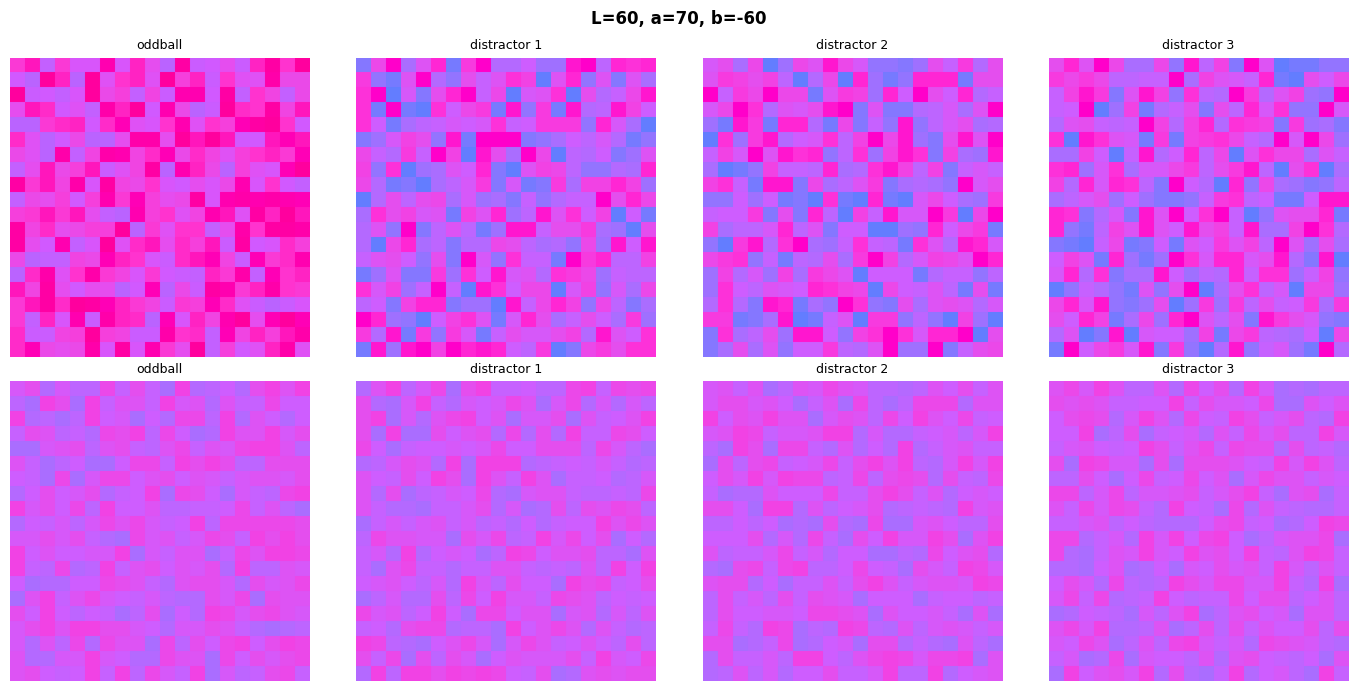

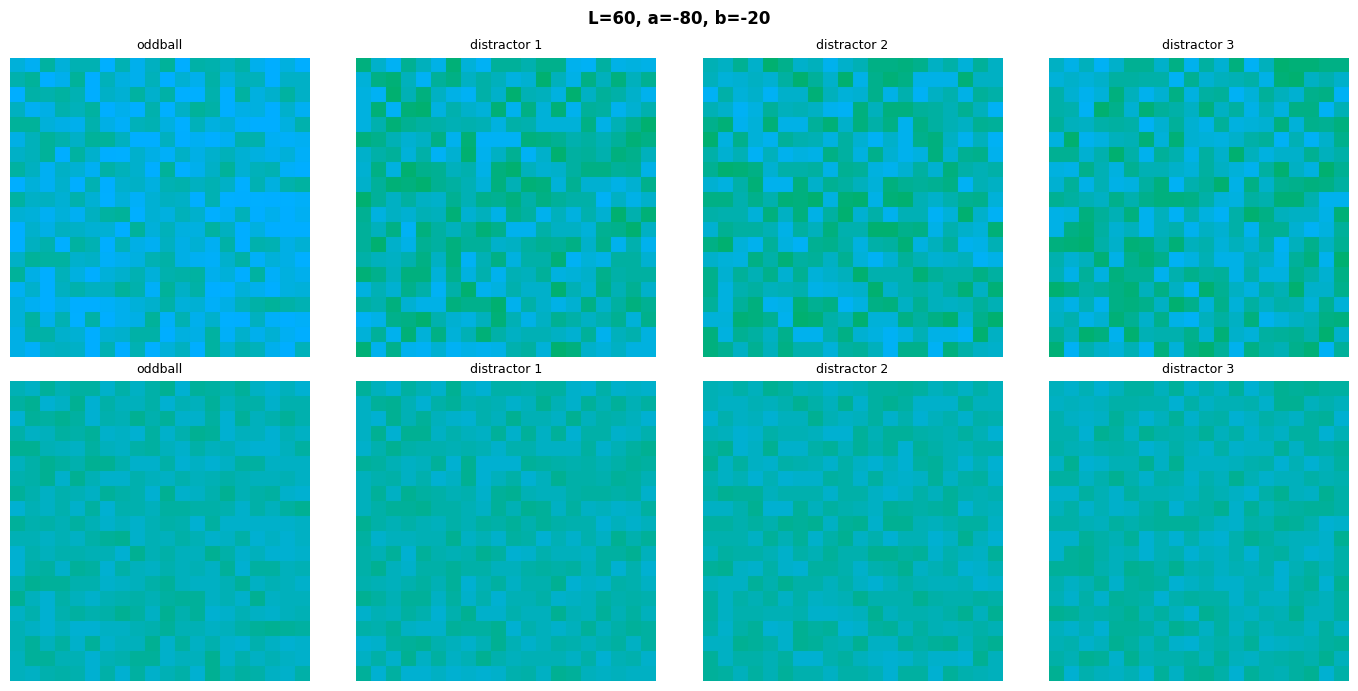

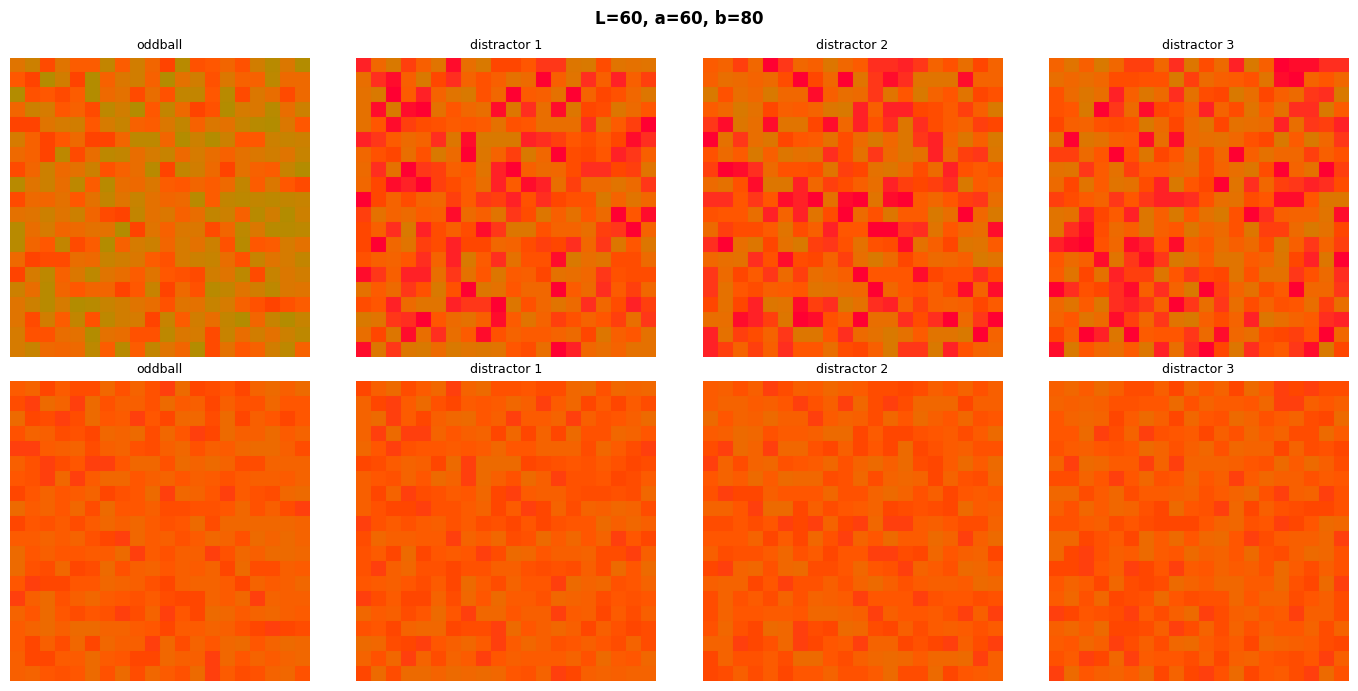

In [38]:
compare_methods(L=60, a=70,  b=-60)   # red-pink
compare_methods(L=60, a=-80, b=-20)   # teal
compare_methods(L=60, a=60,  b=80)    # yellow-green
